In [13]:
with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(text[:500])
print("Total characters:", len(text))

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
Total characters: 1115394


In [3]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [5]:
#b
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=500,
    special_tokens=["[PAD]", "[UNK]"]
)

tokenizer.train(files=["input.txt"], trainer=trainer)

In [7]:
print("Vocab size:", tokenizer.get_vocab_size())

Vocab size: 500


In [9]:
sample = "To be, or not to be: that is the question."
encoded = tokenizer.encode(sample)

print("Tokens:", encoded.tokens)
print("IDs:", encoded.ids)

Tokens: ['To', 'be', ',', 'or', 'not', 'to', 'be', ':', 'that', 'is', 'the', 'que', 'st', 'ion', '.']
IDs: [185, 93, 6, 71, 111, 80, 93, 10, 116, 72, 70, 433, 77, 228, 8]


In [17]:
encoded_text = tokenizer.encode(text)
token_ids = encoded_text.ids

print("Total tokens:", len(token_ids))
print(token_ids[:50])

Total tokens: 447717
[405, 15, 91, 47, 64, 73, 10, 394, 281, 114, 298, 99, 108, 422, 44, 136, 129, 6, 393, 79, 363, 8, 13, 78, 10, 31, 152, 250, 6, 363, 8, 405, 15, 91, 47, 64, 73, 10, 316, 156, 133, 56, 84, 314, 90, 42, 143, 129, 80, 275]


In [21]:
tokenizer.save("tinyshakespeare_bpe.json")

In [19]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("tinyshakespeare_bpe.json")

In [21]:
#c
seq_len = 50
inputs = []
targets = []

for i in range(len(token_ids) - seq_len):
    x = token_ids[i : i + seq_len]
    y = token_ids[i + 1 : i + seq_len + 1]
    inputs.append(x)
    targets.append(y)

In [23]:
print("Number of sequences:", len(inputs))
print("Input example:", inputs[0])
print("Target example:", targets[0])

Number of sequences: 447667
Input example: [405, 15, 91, 47, 64, 73, 10, 394, 281, 114, 298, 99, 108, 422, 44, 136, 129, 6, 393, 79, 363, 8, 13, 78, 10, 31, 152, 250, 6, 363, 8, 405, 15, 91, 47, 64, 73, 10, 316, 156, 133, 56, 84, 314, 90, 42, 143, 129, 80, 275]
Target example: [15, 91, 47, 64, 73, 10, 394, 281, 114, 298, 99, 108, 422, 44, 136, 129, 6, 393, 79, 363, 8, 13, 78, 10, 31, 152, 250, 6, 363, 8, 405, 15, 91, 47, 64, 73, 10, 316, 156, 133, 56, 84, 314, 90, 42, 143, 129, 80, 275, 43]


In [25]:
print("Input first 10: ", inputs[0][:10])
print("Target first 10:", targets[0][:10])

Input first 10:  [405, 15, 91, 47, 64, 73, 10, 394, 281, 114]
Target first 10: [15, 91, 47, 64, 73, 10, 394, 281, 114, 298]


In [27]:
#PyTorch tensor
import torch

inputs = torch.tensor(inputs, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

print(inputs.shape)
print(targets.shape)

torch.Size([447667, 50])
torch.Size([447667, 50])


In [29]:
#80% train, 20% val
split_idx = int(0.8 * len(inputs))

train_inputs = inputs[:split_idx]
train_targets = targets[:split_idx]

val_inputs = inputs[split_idx:]
val_targets = targets[split_idx:]

print("Train shape:", train_inputs.shape, train_targets.shape)
print("Val shape:", val_inputs.shape, val_targets.shape)

Train shape: torch.Size([358133, 50]) torch.Size([358133, 50])
Val shape: torch.Size([89534, 50]) torch.Size([89534, 50])


In [31]:
#data loader
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

train_dataset = TensorDataset(train_inputs, train_targets)
val_dataset = TensorDataset(val_inputs, val_targets)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [33]:
x_batch, y_batch = next(iter(train_loader))

print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)
print("First input sample:", x_batch[0][:10])
print("First target sample:", y_batch[0][:10])

x_batch shape: torch.Size([32, 50])
y_batch shape: torch.Size([32, 50])
First input sample: tensor([ 45, 354, 102, 114,  12,  19, 354,  67,  82, 192])
First target sample: tensor([354, 102, 114,  12,  19, 354,  67,  82, 192, 111])


In [37]:
import torch.nn as nn

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len)
        B, T = x.shape
        
        token = self.token_emb(x)  # (B, T, d_model)
        
        positions = torch.arange(0, T, device=x.device).unsqueeze(0)
        pos = self.pos_emb(positions)  # (1, T, d_model)
        
        return token + pos

In [39]:
import math
import torch.nn.functional as F

In [41]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # x: (..., dim)
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return self.scale * (x / rms)

In [43]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, T, d_model)
        T = x.size(1)
        return x + self.pe[:, :T, :]

In [45]:
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        B, T, C = x.shape
        
        Q = self.q_proj(x)   # (B, T, C)
        K = self.k_proj(x)   # (B, T, C)
        V = self.v_proj(x)   # (B, T, C)

        # attention scores
        scores = Q @ K.transpose(-2, -1) / math.sqrt(C)   # (B, T, T)

        # causal mask: future tokens blocked
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)      # (B, T, T)
        attn_output = attn_weights @ V                    # (B, T, C)

        output = self.out_proj(attn_output)               # (B, T, C)
        return output, attn_weights

In [47]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

In [49]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = SelfAttention(d_model)
        self.norm2 = RMSNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff)

    def forward(self, x):
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + attn_out
        
        ffn_out = self.ffn(self.norm2(x))
        x = x + ffn_out
        
        return x, attn_weights

In [51]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, d_ff=256, max_len=50, num_layers=2):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len=max_len)
        
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, d_ff) for _ in range(num_layers)
        ])
        
        self.final_norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # x: (B, T)
        x = self.token_embedding(x)       # (B, T, d_model)
        x = self.pos_encoding(x)          # (B, T, d_model)

        all_attn = []
        for block in self.blocks:
            x, attn_weights = block(x)
            all_attn.append(attn_weights)

        x = self.final_norm(x)
        logits = self.lm_head(x)          # (B, T, vocab_size)
        return logits, all_attn

In [53]:
vocab_size = tokenizer.get_vocab_size()
model = TinyTransformer(vocab_size=vocab_size, d_model=128, d_ff=256, max_len=50, num_layers=2)

x_batch, y_batch = next(iter(train_loader))
logits, attn_list = model(x_batch)

print("x_batch shape:", x_batch.shape)
print("logits shape:", logits.shape)
print("number of attention maps:", len(attn_list))
print("attention map shape:", attn_list[0].shape)

x_batch shape: torch.Size([32, 50])
logits shape: torch.Size([32, 50, 500])
number of attention maps: 2
attention map shape: torch.Size([32, 50, 50])


In [55]:
loss = F.cross_entropy(
    logits.view(-1, vocab_size),
    y_batch.view(-1)
)

print("Loss:", loss.item())

Loss: 6.417585849761963


In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = model.to(device)

learning_rate = 3e-4
epochs = 5

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

Using device: cpu


In [65]:
import random
import numpy as np

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [59]:
def evaluate(model, dataloader, vocab_size, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits, _ = model(x)

            loss = F.cross_entropy(
                logits.reshape(-1, vocab_size),
                y.reshape(-1),
                reduction="sum"
            )

            total_loss += loss.item()
            total_tokens += y.numel()

    avg_loss = total_loss / total_tokens
    return avg_loss

In [67]:
train_losses = []
val_losses = []
val_ppls = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0
    total_train_tokens = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits, _ = model(x)

        loss = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            y.reshape(-1),
            reduction="mean"
        )

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * y.numel()
        total_train_tokens += y.numel()

    avg_train_loss = total_train_loss / total_train_tokens
    avg_val_loss = evaluate(model, val_loader, vocab_size, device)
    val_ppl = math.exp(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_ppls.append(val_ppl)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val PPL: {val_ppl:.4f}")

Epoch 1/5 | Train Loss: 2.9926 | Val Loss: 4.2541 | Val PPL: 70.3922
Epoch 2/5 | Train Loss: 2.8347 | Val Loss: 4.3656 | Val PPL: 78.6939
Epoch 3/5 | Train Loss: 2.7368 | Val Loss: 4.4636 | Val PPL: 86.7996
Epoch 4/5 | Train Loss: 2.6672 | Val Loss: 4.5672 | Val PPL: 96.2734
Epoch 5/5 | Train Loss: 2.6147 | Val Loss: 4.6571 | Val PPL: 105.3276


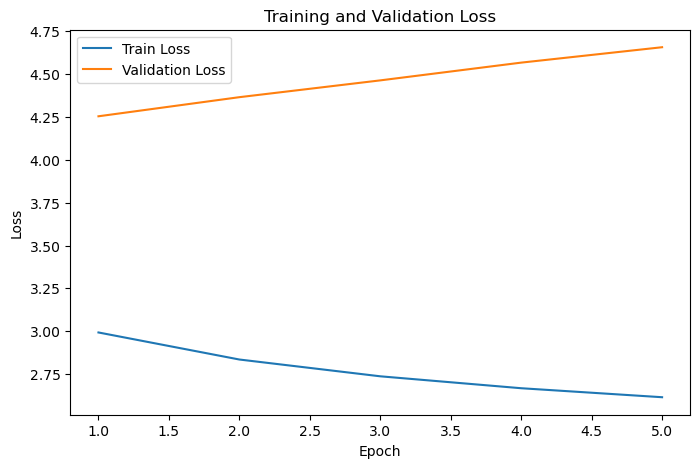

In [70]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [74]:
print("Validation PPL by epoch:", val_ppls)
print("Best Validation PPL:", min(val_ppls))
print("Final Validation PPL:", val_ppls[-1])

Validation PPL by epoch: [70.3922419491447, 78.69392481171884, 86.79959331775001, 96.27339423537964, 105.32760396561463]
Best Validation PPL: 70.3922419491447
Final Validation PPL: 105.32760396561463


In [76]:
model.eval()

x_batch, y_batch = next(iter(val_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    logits, attn_list = model(x_batch)

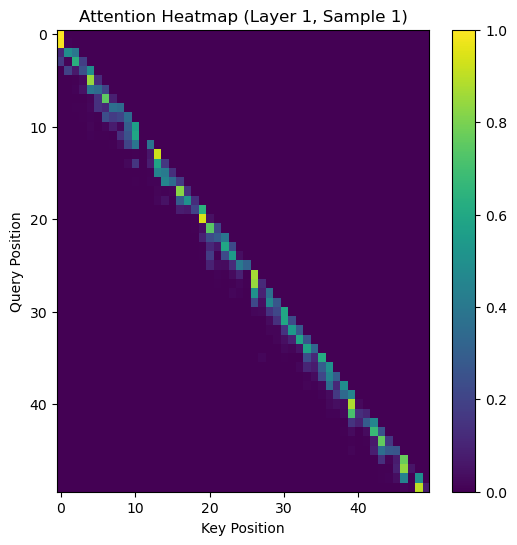

In [78]:
attn = attn_list[0][0].detach().cpu()   # shape: (50, 50)

plt.figure(figsize=(6, 6))
plt.imshow(attn, aspect="auto")
plt.colorbar()
plt.title("Attention Heatmap (Layer 1, Sample 1)")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.savefig("attention_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [82]:
sample_ids = x_batch[0].detach().cpu().tolist()
sample_tokens = [tokenizer.id_to_token(i) for i in sample_ids]
print(sample_tokens[:20])

['IS', 'AB', 'EL', 'LA', ':', 'To', 'who', 'm', 'should', 'I', 'com', 'pl', 'ain', '?', 'D', 'id', 'I', 'tell', 'this', ',']


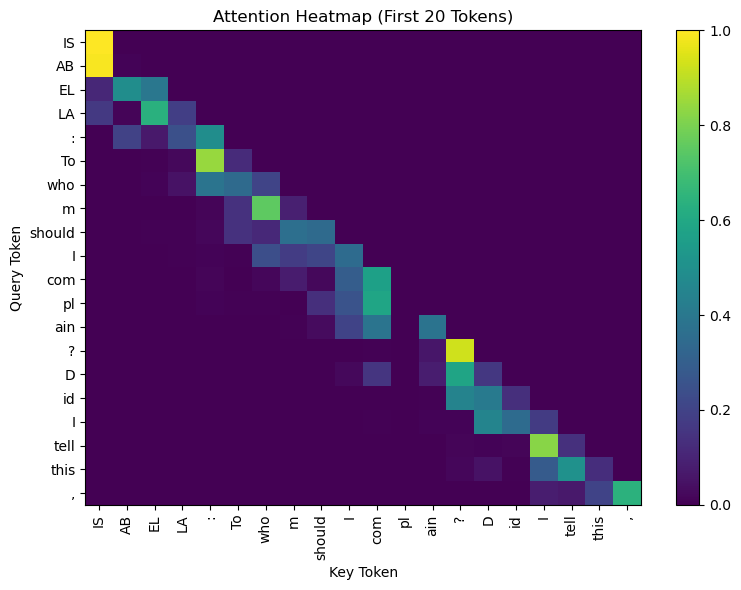

In [84]:
n = 20
attn_small = attn[:n, :n]
tokens_small = sample_tokens[:n]

plt.figure(figsize=(8, 6))
plt.imshow(attn_small, aspect="auto")
plt.colorbar()
plt.xticks(range(n), tokens_small, rotation=90)
plt.yticks(range(n), tokens_small)
plt.title("Attention Heatmap (First 20 Tokens)")
plt.xlabel("Key Token")
plt.ylabel("Query Token")
plt.tight_layout()
plt.savefig("attention_heatmap_tokens.png", dpi=300, bbox_inches="tight")
plt.show()

In [86]:
def generate_text(model, tokenizer, prompt, max_new_tokens=30, device="cpu"):
    model.eval()
    
    # encode prompt
    input_ids = tokenizer.encode(prompt).ids
    x = torch.tensor([input_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
           
            x_cond = x[:, -50:]

            logits, _ = model(x_cond)
            next_token_logits = logits[:, -1, :]   
            probs = torch.softmax(next_token_logits, dim=-1)

            next_token = torch.argmax(probs, dim=-1, keepdim=True)  # greedy
            x = torch.cat([x, next_token], dim=1)

    output_ids = x[0].detach().cpu().tolist()
    generated_text = tokenizer.decode(output_ids)
    return generated_text

In [88]:
prompt = "To be or not"
generated = generate_text(model, tokenizer, prompt, max_new_tokens=30, device=device)
print(generated)

To be or not so much the w ond er ful , and I will take my heart to me , And I will not b u y a thou s and time s


In [90]:
print(generate_text(model, tokenizer, "What is", 30, device))
print(generate_text(model, tokenizer, "I will", 30, device))
print(generate_text(model, tokenizer, "The king", 30, device))

What is ' t , ' tis my p ow er , I ' ll be ar my wi fe , and I will not b u y a way . M
I will not b u y the c o st , And all the wor ld of the king ly g if t . M EN EN IUS : I t is
The king shall be de po se d ? B EN V OL IO : A way ! a way ! a way ! how to ward s our coun t en


In [92]:
def build_model(vocab_size):
    model = TinyTransformer(
        vocab_size=vocab_size,
        d_model=128,
        d_ff=256,
        max_len=50,
        num_layers=2
    )
    return model.to(device)

In [94]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [98]:
model_lr_1e4 = build_model(vocab_size)
optimizer = torch.optim.AdamW(model_lr_1e4.parameters(), lr=1e-4)

epochs_lr1e4 = 5

train_losses_lr1e4 = []
val_losses_lr1e4 = []
val_ppls_lr1e4 = []

for epoch in range(epochs_lr1e4):
    model_lr_1e4.train()
    total_train_loss = 0.0
    total_train_tokens = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits, _ = model_lr_1e4(x)

        loss = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            y.reshape(-1),
            reduction="mean"
        )

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * y.numel()
        total_train_tokens += y.numel()

    avg_train_loss = total_train_loss / total_train_tokens

    model_lr_1e4.eval()
    total_val_loss = 0.0
    total_val_tokens = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            logits, _ = model_lr_1e4(x)

            loss = F.cross_entropy(
                logits.reshape(-1, vocab_size),
                y.reshape(-1),
                reduction="sum"
            )

            total_val_loss += loss.item()
            total_val_tokens += y.numel()

    avg_val_loss = total_val_loss / total_val_tokens
    val_ppl = math.exp(avg_val_loss)

    train_losses_lr1e4.append(avg_train_loss)
    val_losses_lr1e4.append(avg_val_loss)
    val_ppls_lr1e4.append(val_ppl)

    print(f"LR=1e-4 | Epoch {epoch+1}/{epochs_lr1e4} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val PPL: {val_ppl:.4f}")

LR=1e-4 | Epoch 1/5 | Train Loss: 3.9469 | Val Loss: 4.1795 | Val PPL: 65.3319
LR=1e-4 | Epoch 2/5 | Train Loss: 3.3668 | Val Loss: 4.1403 | Val PPL: 62.8222
LR=1e-4 | Epoch 3/5 | Train Loss: 3.1791 | Val Loss: 4.1627 | Val PPL: 64.2423
LR=1e-4 | Epoch 4/5 | Train Loss: 3.0627 | Val Loss: 4.2056 | Val PPL: 67.0576
LR=1e-4 | Epoch 5/5 | Train Loss: 2.9780 | Val Loss: 4.2565 | Val PPL: 70.5642


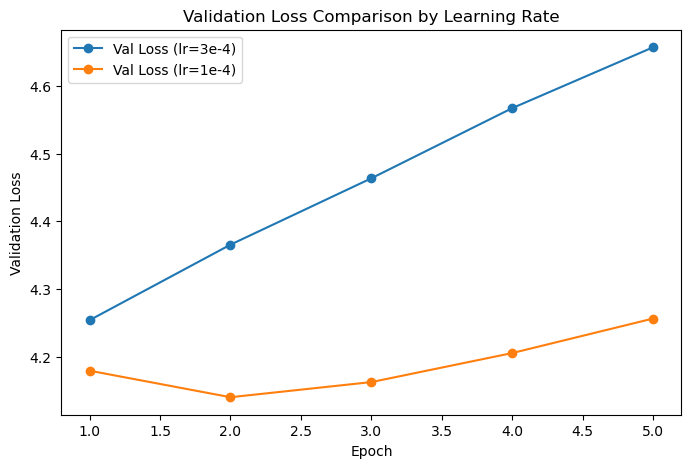

In [99]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label="Val Loss (lr=3e-4)")
plt.plot(range(1, len(val_losses_lr1e4) + 1), val_losses_lr1e4, marker='o', label="Val Loss (lr=1e-4)")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison by Learning Rate")
plt.legend()
plt.savefig("lr_comparison_val_loss.png", dpi=300, bbox_inches="tight")
plt.show()

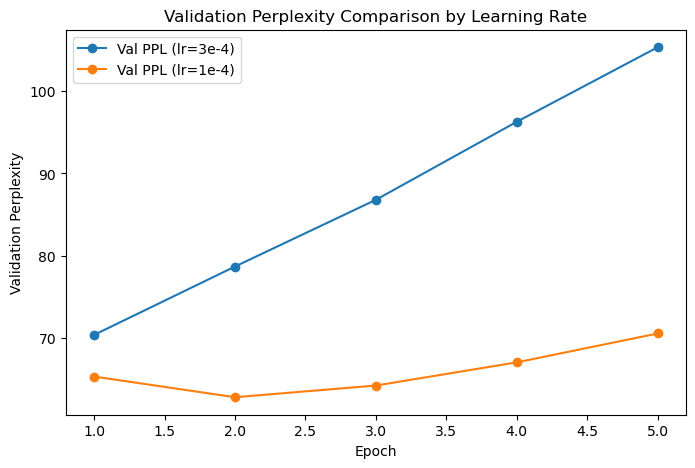

In [100]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(val_ppls) + 1), val_ppls, marker='o', label="Val PPL (lr=3e-4)")
plt.plot(range(1, len(val_ppls_lr1e4) + 1), val_ppls_lr1e4, marker='o', label="Val PPL (lr=1e-4)")

plt.xlabel("Epoch")
plt.ylabel("Validation Perplexity")
plt.title("Validation Perplexity Comparison by Learning Rate")
plt.legend()
plt.savefig("lr_comparison_val_ppl.png", dpi=300, bbox_inches="tight")
plt.show()

In [101]:
print("Baseline (lr=3e-4)")
print("Best Val Loss:", min(val_losses))
print("Best Val PPL:", min(val_ppls))
print("Best Epoch:", val_losses.index(min(val_losses)) + 1)

print("\nComparison (lr=1e-4)")
print("Best Val Loss:", min(val_losses_lr1e4))
print("Best Val PPL:", min(val_ppls_lr1e4))
print("Best Epoch:", val_losses_lr1e4.index(min(val_losses_lr1e4)) + 1)

Baseline (lr=3e-4)
Best Val Loss: 4.2540830575055635
Best Val PPL: 70.3922419491447
Best Epoch: 1

Comparison (lr=1e-4)
Best Val Loss: 4.140309166769049
Best Val PPL: 62.822240996380906
Best Epoch: 2


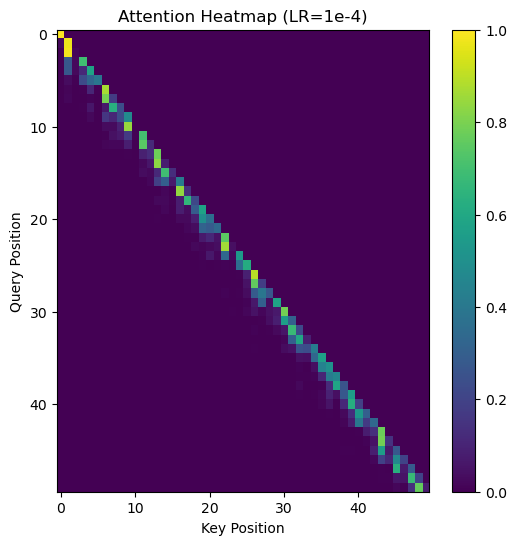

In [106]:
model_lr_1e4.eval()

x_batch, y_batch = next(iter(val_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    logits, attn_list = model_lr_1e4(x_batch)

attn = attn_list[0][0].detach().cpu()  # 第一层，第一个样本

plt.figure(figsize=(6,6))
plt.imshow(attn, aspect="auto")
plt.colorbar()
plt.title("Attention Heatmap (LR=1e-4)")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.savefig("attention_heatmap_lr1e4.png", dpi=300, bbox_inches="tight")
plt.show()

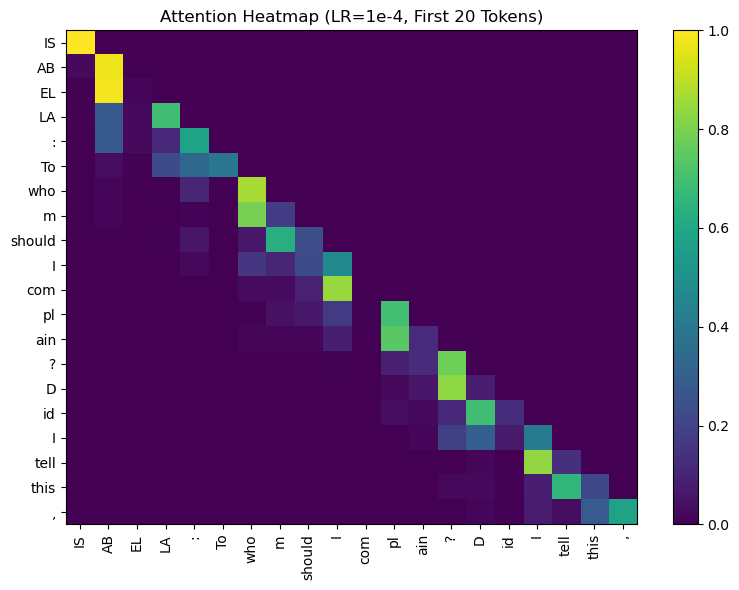

In [108]:
sample_ids = x_batch[0].detach().cpu().tolist()
sample_tokens = [tokenizer.id_to_token(i) for i in sample_ids]

n = 20
attn_small = attn[:n, :n]
tokens_small = sample_tokens[:n]

plt.figure(figsize=(8,6))
plt.imshow(attn_small, aspect="auto")
plt.colorbar()
plt.xticks(range(n), tokens_small, rotation=90)
plt.yticks(range(n), tokens_small)
plt.title("Attention Heatmap (LR=1e-4, First 20 Tokens)")
plt.tight_layout()
plt.savefig("attention_tokens_lr1e4.png", dpi=300, bbox_inches="tight")
plt.show()

In [110]:
print(generate_text(model_lr_1e4, tokenizer, "To be or not", 30, device))
print(generate_text(model_lr_1e4, tokenizer, "What is", 30, device))
print(generate_text(model_lr_1e4, tokenizer, "I will", 30, device))
print(generate_text(model_lr_1e4, tokenizer, "The king", 30, device))

To be or not so , I ' ll be g in to the c rown , And , as I am a ble to be d , and I ' ll be g
What is a po or , I ' ll be g in to the c rown , And , as I am a ble to be d , and I ' ll
I will not be t ter . C L AR EN C E : I ' ll be your f o llow you , sir , and I ' ll be g
The king hath w r ong s of t en , and I ' ll be g in s , and f u ll of s or row , And , as
